### **Overview**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure the speed of processing. Your goal is to understand what factors make a car more or less expensive. As a result of your analysis, you should provide clear recommendations to your client, a used car dealership, as to what consumers value in a used car.
##To frame the task, throughout these practical applications, we will refer to a standard process in the industry for data projects called CRISP-DM. This process provides a framework for working through a data problem. Your first step in this application will be to read through a brief overview of CRISP-DM Links to an external site..

### **Problem Statement**

What features of cars do consumers find more valuable? What car features should used car dealerships focus on when stocking cars and determine features that customers are willing to pay more for.


### **Data Exploration & Preparation**


In [352]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=pd.errors.Pandas4Warning)
warnings.filterwarnings('ignore', message='Found unknown categories')

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import ConvergenceWarning





In [353]:
vehicles = pd.read_csv('/Users/summerscleaning/Documents/data/vehicles.csv')
print(vehicles.shape)
vehicles.head()


(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [354]:
vehicles.info()


<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [355]:
# percent missing for each column
missing = vehicles.isna().mean().sort_values(ascending=False) * 100
missing.round(1)

size            71.8
cylinders       41.6
condition       40.8
VIN             37.7
drive           30.6
paint_color     30.5
type            21.8
manufacturer     4.1
title_status     1.9
model            1.2
odometer         1.0
fuel             0.7
transmission     0.6
year             0.3
id               0.0
region           0.0
price            0.0
state            0.0
dtype: float64

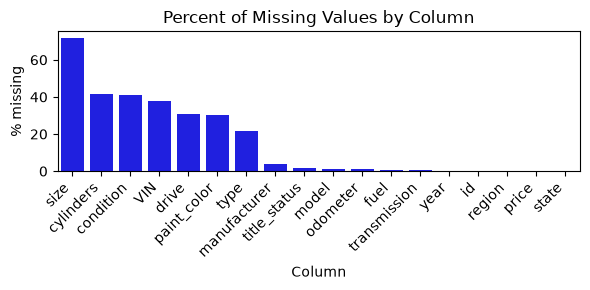

In [356]:
plt.figure(figsize=(6, 3))
sns.barplot(x=missing.index, y=missing.values, color='blue')
plt.title('Percent of Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('% missing')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

** `size` is missing for about 72% of rows, so I will drop it. 

`condition`, `cylinders`, `drive`, `paint_color`, `type` and `VIN` are missing 20-40%. However, dropping all those rows would lose most of the data, I will fill missing with an `'unknown'`.

In [357]:
vehicles.describe().round(0)

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.0,422480.0
mean,7.311487e+09,7.519900e+04,2011.0,98043.0
std,4.473170e+06,1.218228e+07,9.0,213882.0
min,7.207408e+09,0.000000e+00,1900.0,0.0
25%,7.308143e+09,5.900000e+03,2008.0,37704.0
50%,7.312621e+09,1.395000e+04,2013.0,85548.0
75%,7.315254e+09,2.648600e+04,2017.0,133542.0
max,7.317101e+09,3.736929e+09,2022.0,10000000.0


There are some data quality issues. 
1. `price` has some zeros and some entries are 3.7 billion which shows some typoes.
2. `odometer` goes all the way to 10,000,0000 miles which is not accurate.
3. `year` goes all the way to 1900, which are antiques/collector cars and don't really fit a normal used car lot. 
    

In [358]:
# how many unique values in each text column
vehicles.select_dtypes('object').nunique().sort_values(ascending=False)

VIN             118246
model            29649
region             404
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

In [359]:
#Exploring data
vehicles['model'].dropna()


27        sierra 1500 crew cab slt
28                  silverado 1500
29             silverado 1500 crew
30            tundra double cab sr
31                       f-150 xlt
                    ...           
426875           maxima s sedan 4d
426876    s60 t5 momentum sedan 4d
426877            xt4 sport suv 4d
426878             es 350 sedan 4d
426879    4 series 430i gran coupe
Name: model, Length: 421603, dtype: str

In [360]:
vehicles['region'].dropna()

0                       prescott
1                   fayetteville
2                   florida keys
3         worcester / central MA
4                     greensboro
                   ...          
426875                   wyoming
426876                   wyoming
426877                   wyoming
426878                   wyoming
426879                   wyoming
Name: region, Length: 426880, dtype: str

`model` has 29K unique values and is not in standardized free text ("sierra 1500" , silverado 1500 crew") it will require extra work to tag the rows with similar test and some will be left out if not determine or incorrectly bundled. `region` aslo has 400+ values and overlaps with state. `id` and `VIN` are identifiers or more like an data key and will not tell us much about price so dropping that too.

In [361]:
# check other type of duplicates: same car posted in several regions only differing by id and region
dup_cols = [c for c in vehicles.columns if c not in ['id', 'region']]
print('duplicate listings:', vehicles.duplicated(subset=dup_cols).sum())

duplicate listings: 127371


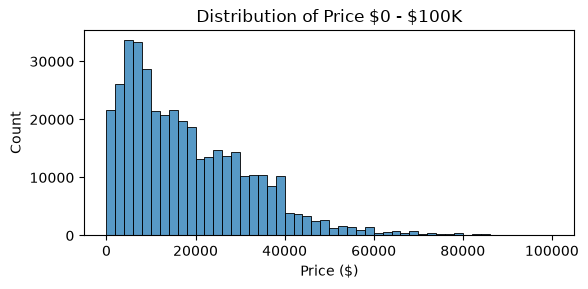

In [362]:
# look at price after removing the crazy values so the plot is readable
price_ok = vehicles.query('price > 0 and price < 100000')['price']

plt.figure(figsize=(6, 3))
sns.histplot(price_ok, bins=50)
plt.title(r'Distribution of Price \$0 - \$100K')
plt.xlabel('Price ($)')

plt.tight_layout()
plt.show()

Price is strongly right skewed (lots of cheap cars, a long tail of expensive ones). Will try the log of price to see if its a shape we can better model. 

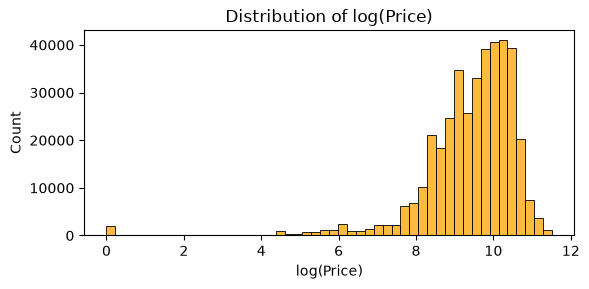

In [363]:
price_ok = vehicles.query('price > 0 and price < 100000')['price']

plt.figure(figsize=(6, 3))
sns.histplot(np.log(price_ok), bins=50, color='orange')
plt.title('Distribution of log(Price)')
plt.xlabel('log(Price)')

plt.tight_layout()
plt.show()

The data is still skewed but much more representative of a bell curve distribution.

###**Data Preparation**

Cleaning steps (based on what I found above):

1. Drop columns: id, VIN, region, model, size.
2. Drop duplicate listings.
3. Keep prices between 
4. 100,000 (removes $0 placeholders and extreme outliers).
5. Keep odometer between 1 and 300,000 miles.
6. Keep cars from 1995 and newer.
7. Drop the small number of rows missing manufacturer, fuel, title_status, transmission, year or odometer.
8. Fill remaining missing categoricals with 'unknown'.
9. Feature engineering: age = 2022 - year (the newest listings are 2022 models) and a log_price target.

In [364]:
# dropping identify columns with large amounts of unique qualitative data.

cars = vehicles.drop(columns=['id', 'VIN', 'region', 'model', 'size'])
cars = cars.drop_duplicates()

# filter out unrealistic values depending on the column.
cars = cars[(cars['price'] >= 1000) & (cars['price'] <= 100000)]
cars = cars[(cars['odometer'] > 0) & (cars['odometer'] <= 300000)]
cars = cars[cars['year'] >= 1995]

# remove missing rows. These are not going to impact the overall sample since empty values small about 5% in manufacturing for example
cars = cars.dropna(subset=['manufacturer', 'fuel', 'title_status', 'transmission'])


# the rest get their 'unknown' value fill where are unable to drop rows
fill_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color']
cars[fill_cols] = cars[fill_cols].fillna('unknown')


# new features
cars['age'] = 2022 - cars['year']
cars['log_price'] = np.log(cars['price'])
cars = cars.drop(columns='year')


print('rows before:', len(vehicles), ' rows after:', len(cars))
print('missing values left:', cars.isna().sum().sum())


rows before: 426880  rows after: 236939
missing values left: 0


We went from ~427k rows to ~237k. Most of that is duplicates (~130k) and the $0 / bad prices. That still leaves plenty of data to model.

Now some plots of the cleaned data to see how the features relate to price.

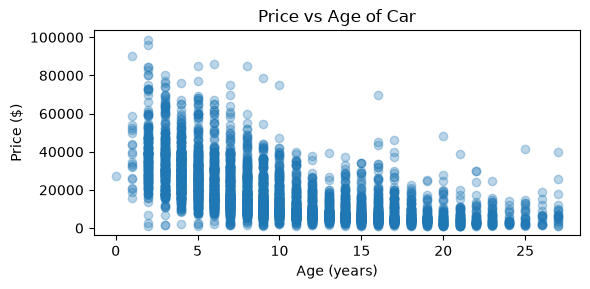

In [365]:
# continuous features vs price (sample so the scatter isn't a solid blob)
sample = cars.sample(5000, random_state=42)
plt.figure(figsize=(6, 3))

plt.plot(sample['age'], sample['price'], 'o', alpha=0.3)
plt.title('Price vs Age of Car')
plt.xlabel('Age (years)')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

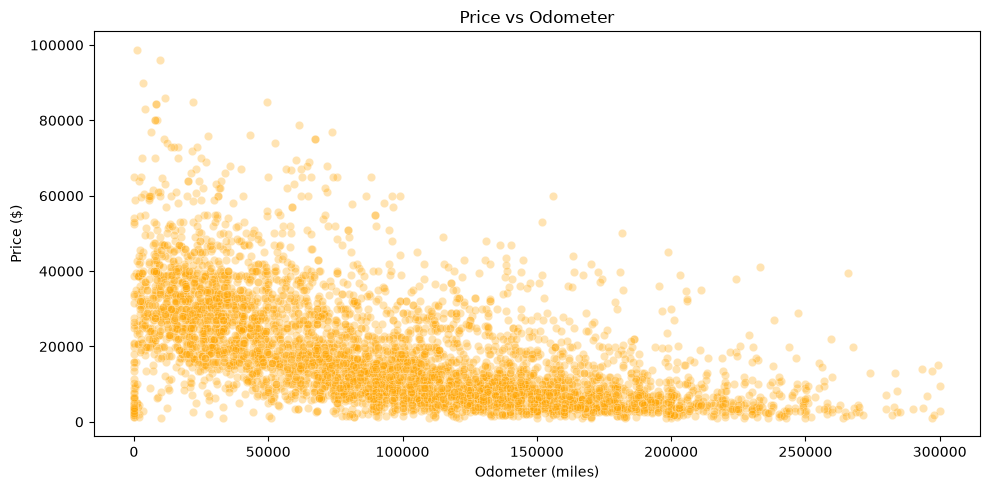

In [366]:
# check price verus odometer
sample = cars.sample(5000, random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='odometer', y='price', alpha=0.3, color='orange')
plt.title('Price vs Odometer')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

From the graphs age and mileage are negatively correlated. There is a big drop in the first few years and then flattens. Age and Odometer reading are correlated with each other which makes sense since older cars tend to have been driven more. Based on the output will try to model as a polynomial curve.

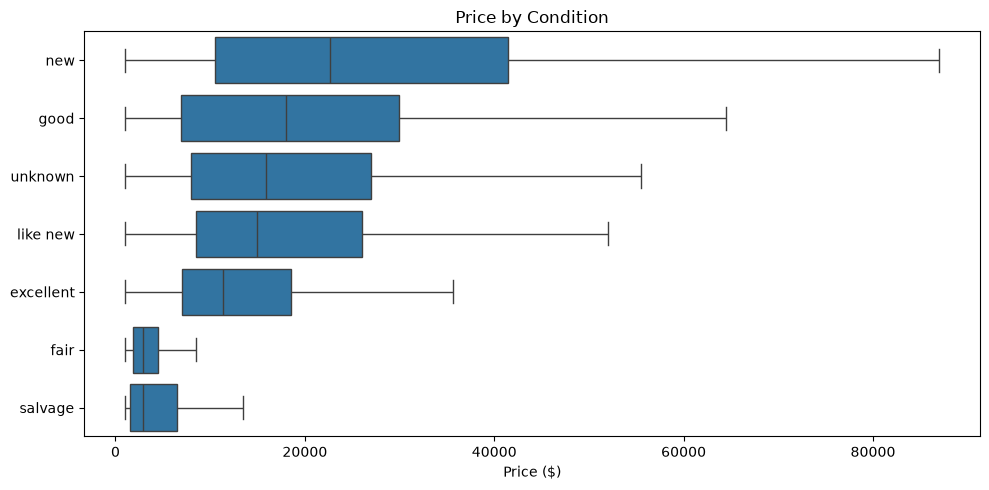

In [367]:
# categorical features vs price - boxplots, sorted by median price
# Condition
order = cars.groupby('condition')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=cars, x='price', y='condition', order=order, showfliers=False)
plt.title('Price by Condition')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

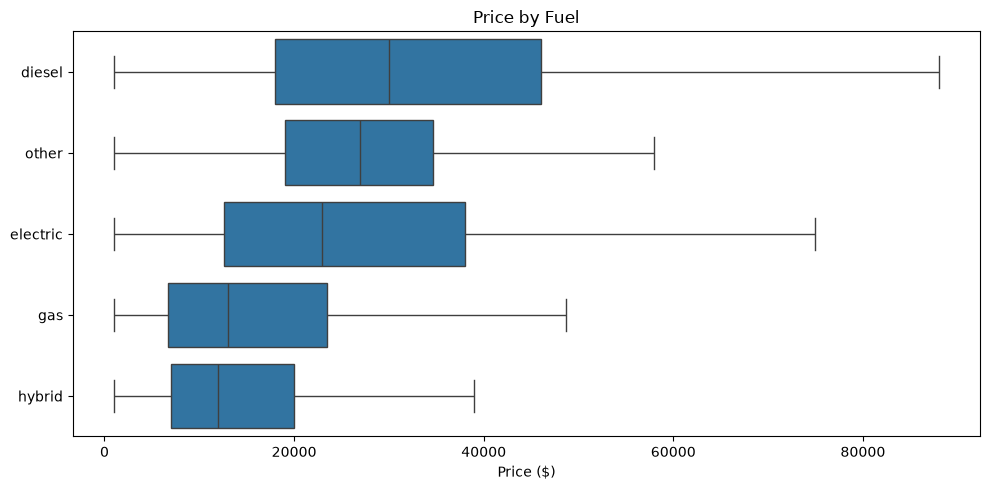

In [368]:
# Fuel
order = cars.groupby('fuel')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=cars, x='price', y='fuel', order=order, showfliers=False)
plt.title('Price by Fuel')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

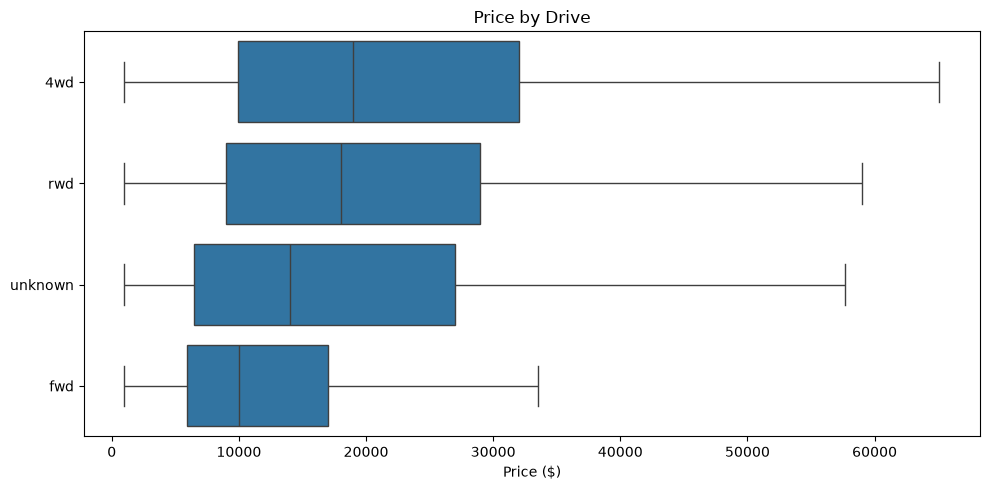

In [369]:
# Drive
order = cars.groupby('drive')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=cars, x='price', y='drive', order=order, showfliers=False)
plt.title('Price by Drive')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

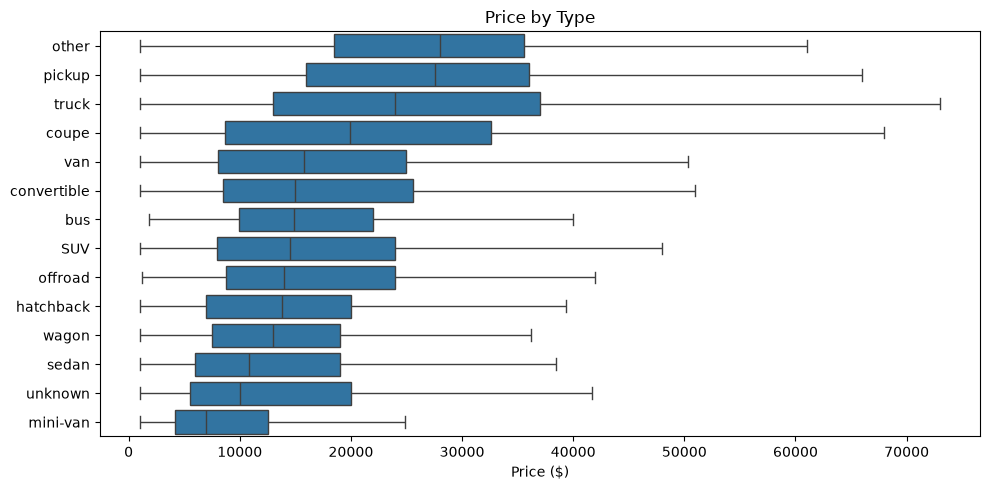

In [370]:
# Type
order = cars.groupby('type')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=cars, x='price', y='type', order=order, showfliers=False)
plt.title('Price by Type')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

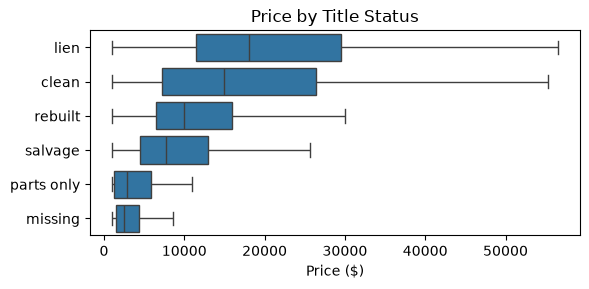

In [371]:
# Title status
order = cars.groupby('title_status')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(6, 3))
sns.boxplot(data=cars, x='price', y='title_status', order=order, showfliers=False)
plt.title('Price by Title Status')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

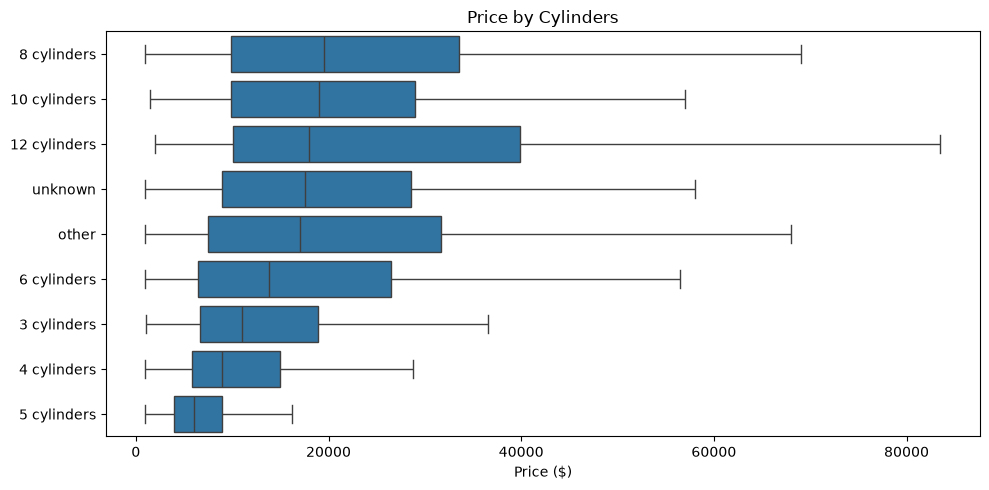

In [372]:
# Cylinders
order = cars.groupby('cylinders')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=cars, x='price', y='cylinders', order=order, showfliers=False)
plt.title('Price by Cylinders')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

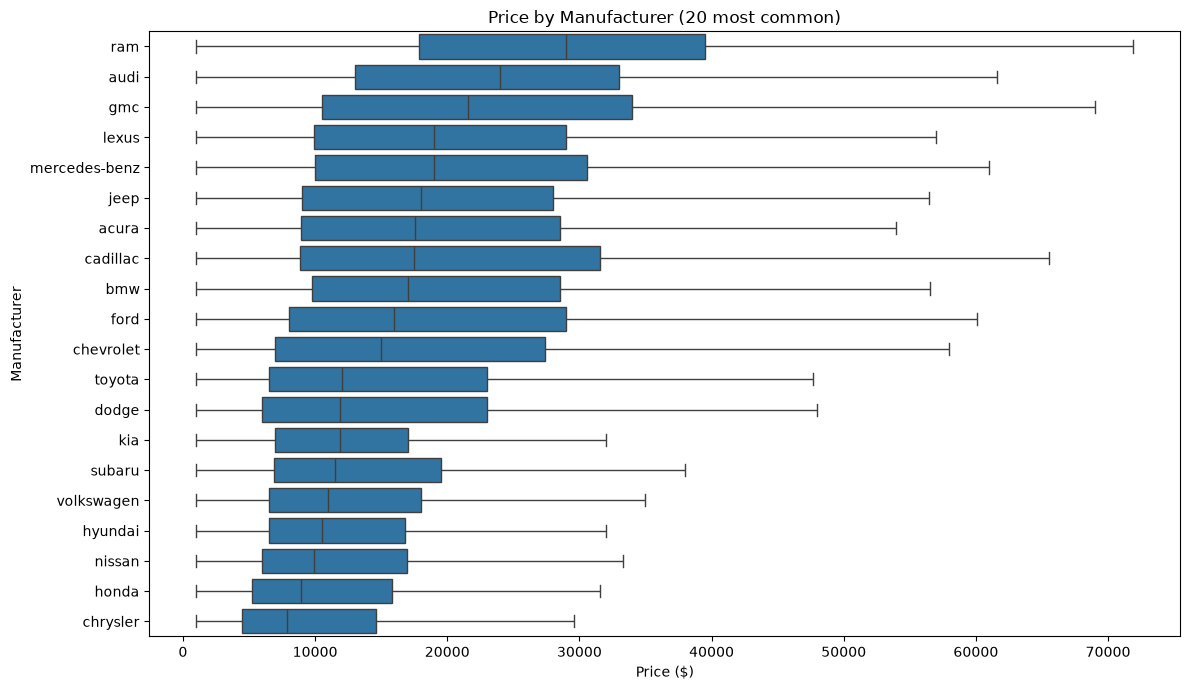

In [373]:
# Get the 20 most common manufacturers
top_makes = cars['manufacturer'].value_counts().head(20).index

# Keep only cars from those manufacturers
top_cars = cars[cars['manufacturer'].isin(top_makes)]

# Sort manufacturers by median price, highest first
medians = top_cars.groupby('manufacturer')['price'].median()
order = medians.sort_values(ascending=False).index

# Plot
plt.figure(figsize=(12, 7))
sns.boxplot(data=top_cars, x='price', y='manufacturer', order=order, showfliers=False)
plt.title('Price by Manufacturer (20 most common)')
plt.xlabel('Price ($)')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.show()

Initial observations from the plots: 

- Diesel cars and pickups/trucks have much higher median prices than gas sedans.
- 4wd and rwd cars sell for more than fwd.
- 8-cylinder cars are more expensive than 4-cylinder ones.
- Cars with salvage/rebuilt/parts-only titles are much cheaper.
- Among the 20 most common brands, Ram, Audi and GMC have the highest median prices; Chrysler, Honda and Nissan the lowest. 

These are just raw medians though, and a lot of them overlap (pickups are usually 4wd, 8-cylinder AND diesel). The regression model helps separate out the effec t of each feature while holding the others constant.


In [374]:
# Setting up features and target, then train/test split
num_features = ['age', 'odometer']
cat_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
                'transmission', 'drive', 'type', 'paint_color', 'state']

X = cars[num_features + cat_features]
y = cars['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape)

(177704, 12) (59235, 12)


In [375]:
# Pick the most "normal" car as the baseline (reference) level for each category
reference_levels = ['ford', 'good', '4 cylinders', 'gas', 'clean',
                    'automatic', 'fwd', 'sedan', 'white', 'ca']

def make_preprocessor(degree=1):
    """Polynomial + scaling for numeric columns, one-hot encoding for categorical columns"""
    numeric_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler())
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, num_features),
        ('cat', OneHotEncoder(drop=reference_levels, handle_unknown='ignore'), cat_features)
    ])

### Modeling

**Evaluation metric:** I'm using **RMSE on log(price)** via neg_mean_squared_error in sklearn during cross-validation and grid search. Since the target is log price, an RMSE of 0.40 roughly means predictions are typically off by about 40%. RMSE punishes big mistakes more than small ones, which is what we want since badly mispricing a car costs the dealer money. For the final report I also convert predictions back to dollars and give **MAE in dollars**, because "off by about \$4,400 on average" is easier for a dealer to understand. 

**Models:**
1. A baseline that always predicts the average (to see if the models actually learn something).
2. Linear Regression (no regularization).
3. Ridge Regression, grid search over alpha and polynomial degree of age/odometer.
4. Lasso Regression, grid search over alpha and polynomial degree.

All models use 5-fold cross-validation on the training set. I will use the test set only at the very end.

In [376]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# baseline: always predict the mean log price
baseline_pred = np.full(len(y_train), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_train, baseline_pred))

print('Baseline RMSE (log price):' + str(round(baseline_rmse,3)))



Baseline RMSE (log price):0.849


In [377]:
# Model 1: plain linear regression


lr_pipe = Pipeline([('prep', make_preprocessor(degree=1)), ('model', LinearRegression())])

lr_scores = cross_val_score(lr_pipe, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
lr_cv_rmse = np.sqrt(-lr_scores.mean())


print('Linear Regression CV RMSE:'+ str(round(lr_cv_rmse,3))) 


Linear Regression CV RMSE:0.403


Grid search on the full training set 178k rows is slow, especially for Lasso with polynomial features. To make it faster, I run the grid search on a random sample of 40,000 training rows to find the best hyperparameters, then refit the best model on the full training set.

In [378]:
# random sample of the training data just for the grid search
X_gs = X_train.sample(40000, random_state=42)
y_gs = y_train.loc[X_gs.index]

# Model 2: Ridge
ridge_pipe = Pipeline([('prep', make_preprocessor()), ('model', Ridge())])
ridge_params = {
    'prep__num__poly__degree': [1, 2, 3],
    'model__alpha': [0.1, 1, 10, 100]
}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=kfold,
                          scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_gs, y_gs)

print('Best Ridge params:', ridge_grid.best_params_)
print('Best Ridge CV RMSE:' + str(round(np.sqrt(-ridge_grid.best_score_),3)))

Best Ridge params: {'model__alpha': 0.1, 'prep__num__poly__degree': 3}
Best Ridge CV RMSE:0.394


In [379]:
# Model 3: Lasso
lasso_pipe = Pipeline([('prep', make_preprocessor()), ('model', Lasso(max_iter=5000))])
lasso_params = {
    'prep__num__poly__degree': [1, 2, 3],
    'model__alpha': [0.0001, 0.001, 0.01]
}
lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=kfold,
                          scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_gs, y_gs)

print('Best Lasso params:', lasso_grid.best_params_)
print('Best Lasso CV RMSE:' + str(round(np.sqrt(-lasso_grid.best_score_),3)))

Best Lasso params: {'model__alpha': 0.0001, 'prep__num__poly__degree': 3}
Best Lasso CV RMSE:0.395


In [380]:
# refit all three on the full training data
lr_pipe.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_.fit(X_train, y_train)

lasso_coefs = best_lasso.named_steps['model'].coef_
print('Lasso set ' + str((lasso_coefs == 0).sum()) + ' of ' + str(len(lasso_coefs))+ ' coefficients to zero')

Lasso set 18 of 152 coefficients to zero


### **Evaluation**

Comparing all models on the test set (data none of the models have seen).

In [381]:
def evaluate(name, model):
    pred_log = model.predict(X_test)
    return {
        'model': name,
        'RMSE (log price)': np.sqrt(mean_squared_error(y_test, pred_log)),
        'R2': r2_score(y_test, pred_log),
        'MAE ($)': mean_absolute_error(np.exp(y_test), np.exp(pred_log)),
    }

baseline_test = np.full(len(y_test), y_train.mean())
results = pd.DataFrame([
    {'model': 'Baseline (mean)',
     'RMSE (log price)': np.sqrt(mean_squared_error(y_test, baseline_test)),
     'R2': r2_score(y_test, baseline_test),
     'MAE ($)': mean_absolute_error(np.exp(y_test), np.exp(baseline_test))},
    evaluate('Linear Regression', lr_pipe),
    evaluate('Ridge', best_ridge),
    evaluate('Lasso', best_lasso),
])
results.round(3)

,model,RMSE (log price),R2,MAE ($)
0,Baseline (mean),0.855,-0.000,10655.122
1,Linear Regression,0.407,0.774,4480.081
2,Ridge,0.399,0.783,4416.827
3,Lasso,0.399,0.783,4403.575


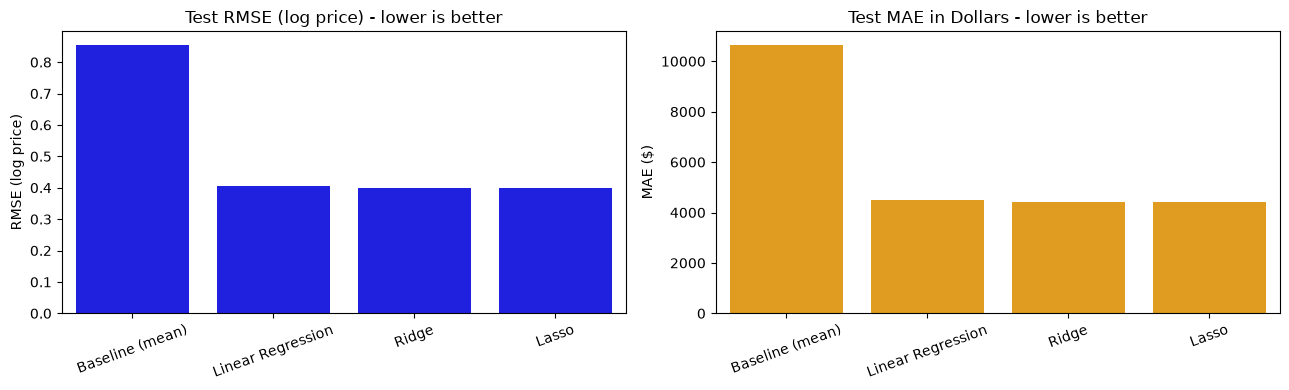

In [382]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=results, x='model', y='RMSE (log price)', ax=axes[0], color='blue')
axes[0].set_title('Test RMSE (log price) - lower is better')
axes[0].set_xlabel('')
sns.barplot(data=results, x='model', y='MAE ($)', ax=axes[1], color='orange')
axes[1].set_title('Test MAE in Dollars - lower is better')
axes[1].set_xlabel('')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Error Interpretation 
- All three models cut the error roughly in half vs the baseline, so they're definitely learning real patterns.
- Ridge and Lasso (with polynomial terms) are a little better than plain linear regression: R² goes from about 0.77 to 0.78, and MAE is around $4,400.
- R² about 0.78 means the features explain about 78% of the variation in log price. The other ~22% is probably stuff we don't have like the exact model/trim, accident history, options, and photos/description quality.
- Ridge and Lasso are basically tied. I'll use Ridge as the final model since it's faster and the scores are the same.

Checking that the errors look reasonable:


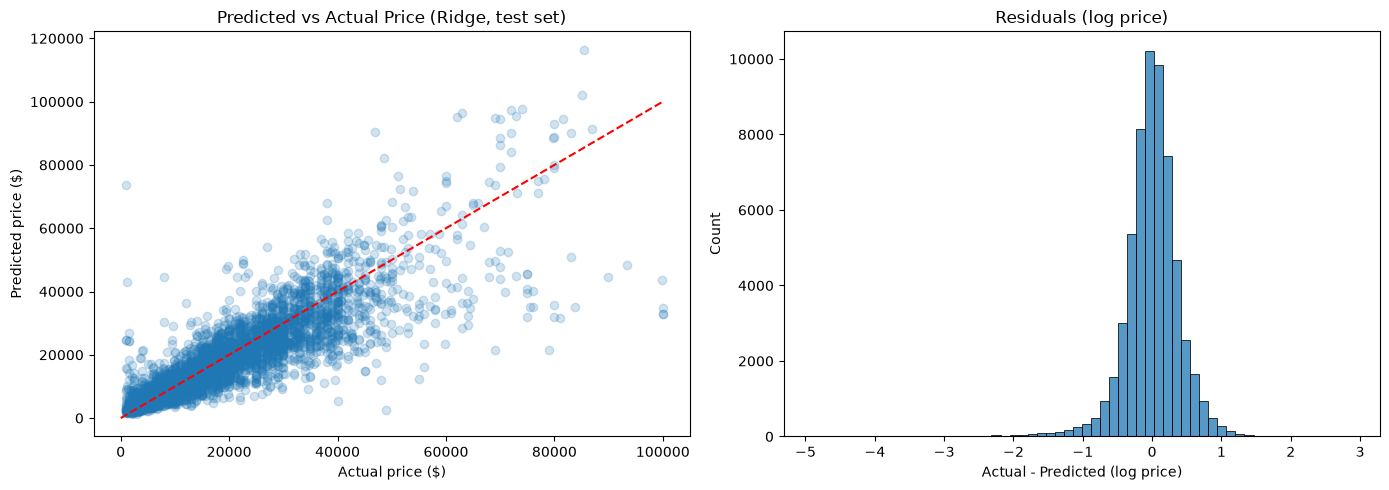

In [383]:
pred_log = best_ridge.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

idx = np.random.RandomState(42).choice(len(y_test), 5000, replace=False)
axes[0].scatter(np.exp(y_test.values[idx]), np.exp(pred_log[idx]), alpha=0.2)
axes[0].plot([0, 100000], [0, 100000], color='red', linestyle='--')
axes[0].set_title('Predicted vs Actual Price (Ridge, test set)')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')

sns.histplot(y_test - pred_log, bins=60, ax=axes[1])
axes[1].set_title('Residuals (log price)')
axes[1].set_xlabel('Actual - Predicted (log price)')
plt.tight_layout()
plt.show()

Points follow the red line pretty well, with more spread for expensive cars. Residuals are centered at 0 and roughly bell shaped, so looks good.

#### Interpreting the model

The best Ridge model uses degree-3 polynomial terms for age and odometer. Those terms (age², age×odometer, etc.) are hard to interpret one by one. So for the **interpretation** I willfit the same kind of model with degree 1 and the numbers left in real units (years, 10k miles). This will help coefficient have a direct meaning.

Because the target is log(price), a coefficient `b` means: *changing this feature changes price by about (e^b - 1) × 100 percent, holding everything else constant*. For categories, the comparison is against the reference level (a gas, 4-cylinder, automatic, fwd, white, Ford sedan in good condition with a clean title in CA).

In [384]:
# interpretable version: numeric features in real units, no scaling/polynomials
X_train_int = X_train.copy()
X_test_int = X_test.copy()
X_train_int['odometer'] = X_train_int['odometer'] / 10000   # per 10k miles
X_test_int['odometer'] = X_test_int['odometer'] / 10000

interp_model = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(drop=reference_levels, handle_unknown='ignore'), cat_features)
    ])),
    ('model', Ridge(alpha=1))
])
interp_model.fit(X_train_int, y_train)
print('Interpretable model test R2: ' + str(round(r2_score(y_test, interp_model.predict(X_test_int)),3)))

coefs = pd.Series(interp_model.named_steps['model'].coef_,
                  index=interp_model.named_steps['prep'].get_feature_names_out())
pct_effect = (np.exp(coefs) - 1) * 100
pct_effect.index = pct_effect.index.str.replace('num__', '').str.replace('cat__', '')

print('Each extra year of age: ' + str(round(pct_effect['age'],3)))
print('Each extra 10,000 miles: ' + str(round(pct_effect['odometer'],3)))

Interpretable model test R2: 0.774
Each extra year of age: -7.359
Each extra 10,000 miles: -3.727


We can see age had a greater inverse relationship to price. 

In [385]:
#Features, split, and reference levels

num_features = ['age', 'odometer']
cat_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
                'transmission', 'drive', 'type', 'paint_color', 'state']

X = cars[num_features + cat_features]
y = cars['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape)

# baseline level for each category (same order as cat_features)
reference_levels = ['ford', 'good', '4 cylinders', 'gas', 'clean',
                    'automatic', 'fwd', 'sedan', 'white', 'ca']

(177704, 12) (59235, 12)


In [386]:
# scale numbers with optional squared terms, one-hot encode categories
def make_preprocessor(degree=1):
    numeric_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scale', StandardScaler())
    ])
    encoder = OneHotEncoder(drop=reference_levels, handle_unknown='ignore')
    preprocessor = ColumnTransformer([
        ('num', numeric_pipe, num_features),
        ('cat', encoder, cat_features)
    ])
    return preprocessor


lasso_pipe = Pipeline([
    ('prep', make_preprocessor(degree=2)),
    ('model', Lasso(max_iter=10000))
])

alphas = [0.0001, 0.001, 0.01, 0.1, 1]
lasso_grid = GridSearchCV(lasso_pipe, {'model__alpha': alphas}, cv=5)
lasso_grid.fit(X_train, y_train)

print('Best alpha:', lasso_grid.best_params_['model__alpha'])

Best alpha: 0.0001


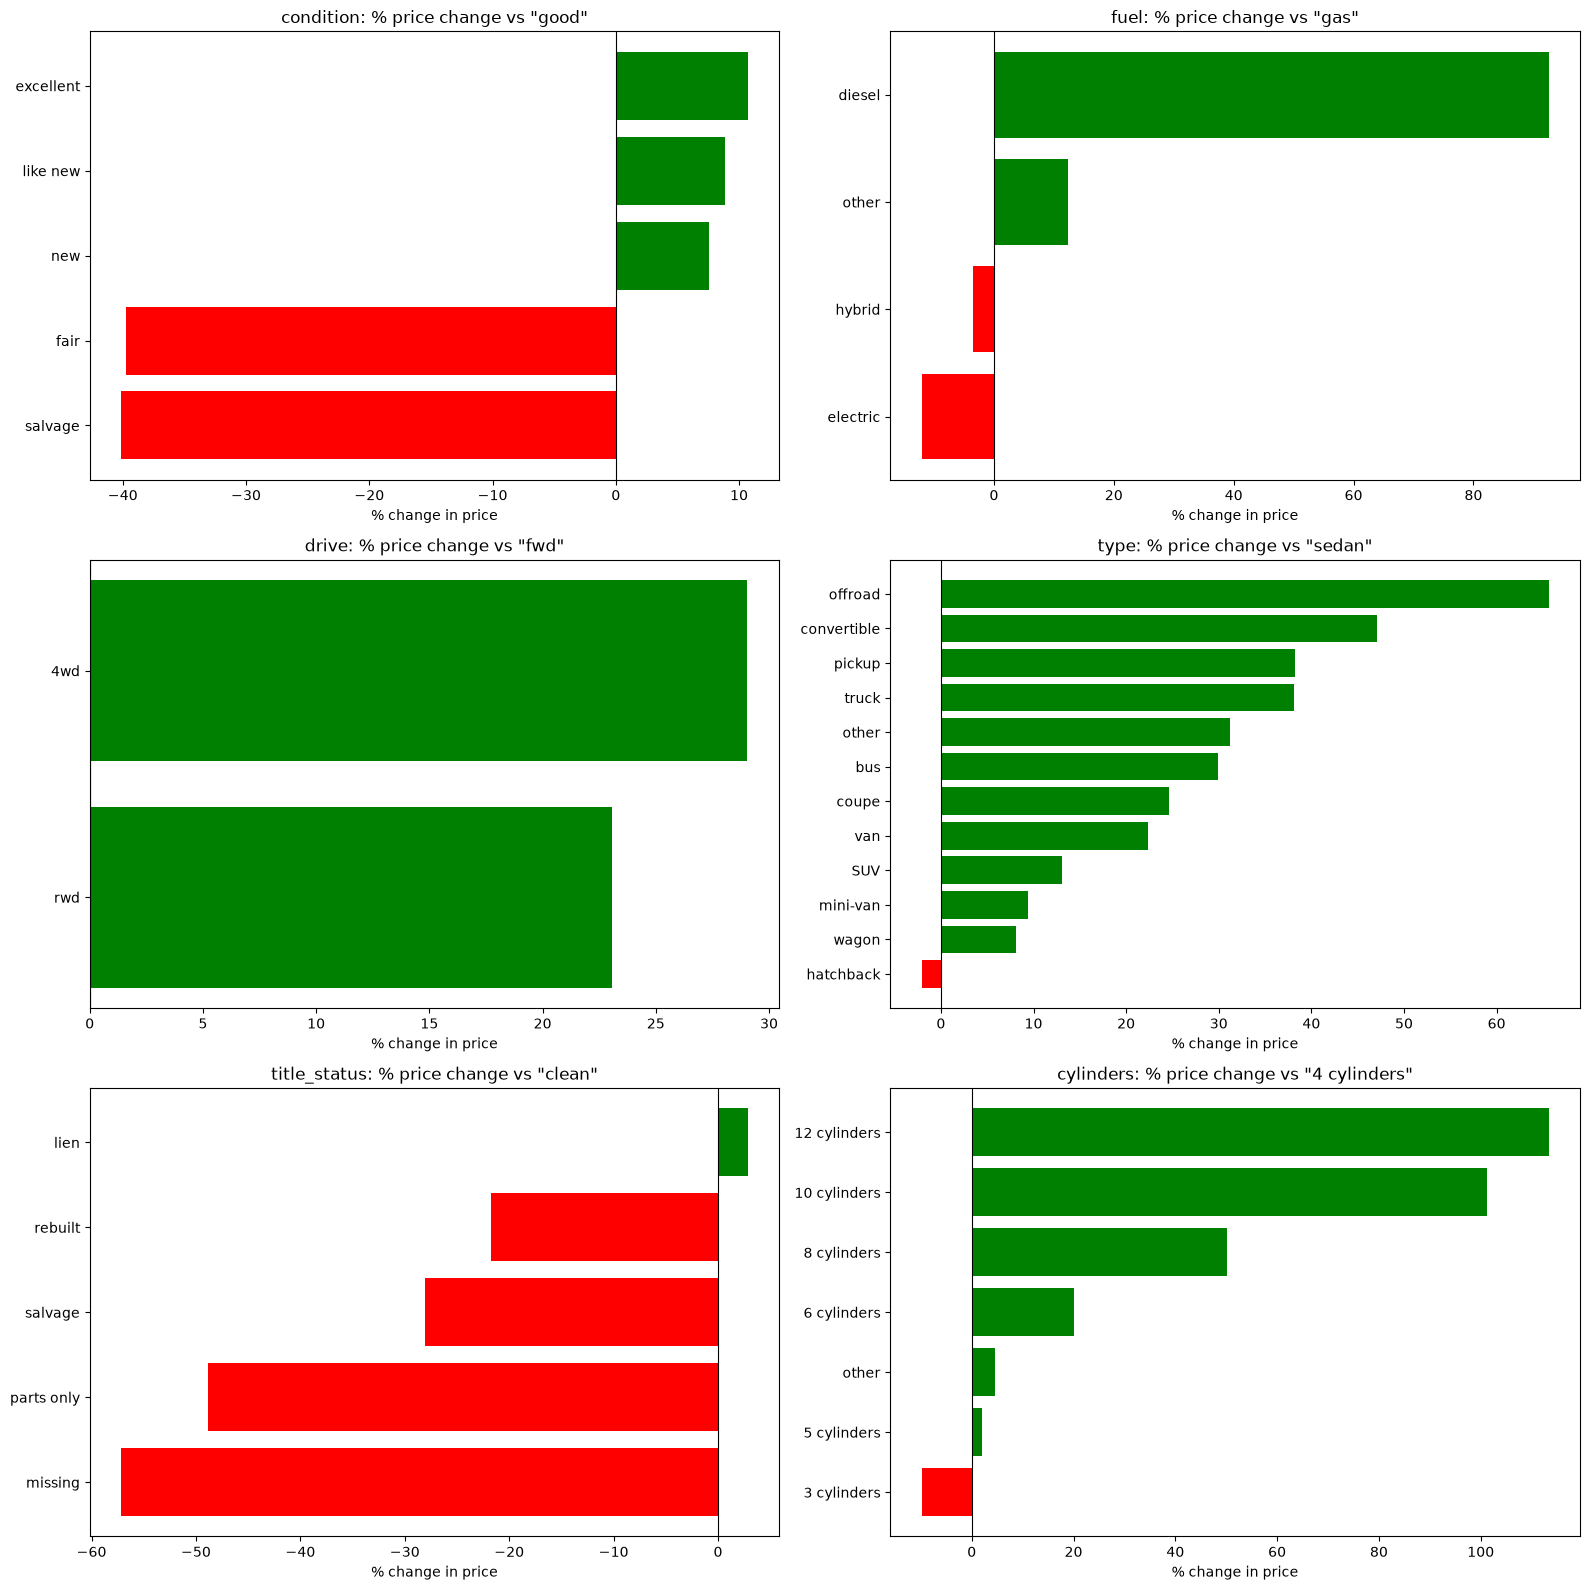

In [387]:
#Plot

groups = ['condition', 'fuel', 'drive', 'type', 'title_status', 'cylinders']
ref_for = dict(zip(cat_features, reference_levels))   # e.g. {'fuel': 'gas', ...}

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i in range(len(groups)):
    group = groups[i]
    ax = axes[i]

    vals = pct_effect[pct_effect.index.str.startswith(group + '_')]
    vals = vals[~vals.index.str.endswith('unknown')]
    vals = vals.sort_values()
    vals.index = vals.index.str.replace(group + '_', '')

    colors = []
    for v in vals:
        if v < 0:
            colors.append('red')
        else:
            colors.append('green')

    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(group + ': % price change vs "' + ref_for[group] + '"')
    ax.set_xlabel('% change in price')

plt.tight_layout()
plt.show()

### Investigate Manufacturer using Ford as baselinne
Choosing Ford as it has a lot of data points.


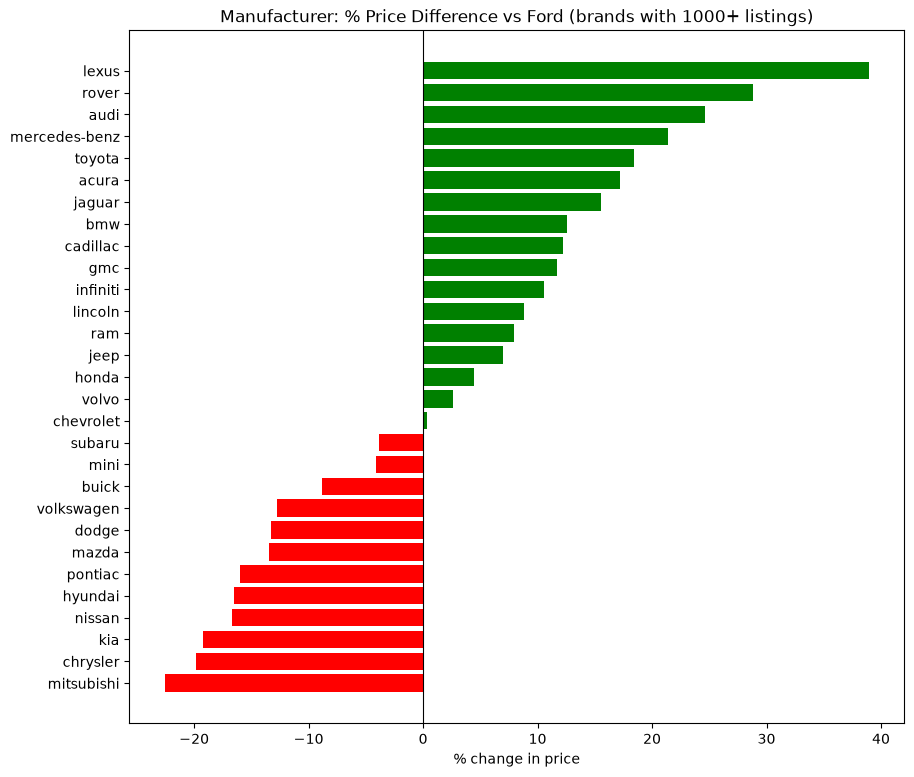

In [388]:
# manufacturer effects compared to ford
make_eff = pct_effect[pct_effect.index.str.startswith('manufacturer_')].sort_values()
make_eff.index = make_eff.index.str.replace('manufacturer_', '')
# only keep brands with enough listings to trust the number
common = cars['manufacturer'].value_counts()
make_eff = make_eff[make_eff.index.isin(common[common >= 1000].index)]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(make_eff.index, make_eff.values, color=['red' if v < 0 else 'green' for v in make_eff])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Manufacturer: % Price Difference vs Ford (brands with 1000+ listings)')
ax.set_xlabel('% change in price')
plt.show()

#### What the model says

- **Age is by far the most important feature**, then **odometer**. Each extra year takes off roughly 7% of price and every 10,000 miles roughly another 4%, holding everything else equal.
- **Fuel / cylinders / drive / type** come next. Compared to a gas 4-cylinder fwd sedan: diesel is worth about 90% more, 8-cylinder cars about 50% more, 4wd about 29% more, and pickups/trucks about 38% more.
- **Title status**: salvage and rebuilt titles cut price by roughly 20-30%, "missing" and "parts only" by around half.
- **Condition**: fair and salvage condition are about 40% less than "good". Excellent is about 11% more than good, but oddly "new" and "like new" come out slightly below excellent. My guess is sellers use these labels loosely and the model already captures most of it through age and miles.
- **Manufacturer**: this is where the model really helps. In the raw boxplot Toyota looked cheaper than Ford, but at the same age and mileage Toyota is worth about 19% more. Lexus +40% also command a premium over Ford at the same age/mileage; Mitsubishi, Kia, Chrysler, Nissan and Hyundai sell for roughly 16-23% less per the model.
- **Paint color** barely matters (within about 7% give or take).

#### Concerns 

The model is good enough for identifying the main price drivers, which is what the client asked for. It's not accurate enough to price a single car on its own (off by about \$4,400 on average), so if the dealer wanted a pricing tool will need to find a model with lower pricing error

#### Summary
This model explains about **78%** of the variation in used car prices. The most important factors are **how old the car is** and **how many miles it has**, followed by the **type of vehicle and drivetrain** (trucks, 4WD, diesel, bigger engines), **title status**, and **brand**.

#### Key findings (holding other factors equal)
#### - Factor - Effect on price

- **Age and mileage:** drag prices down the fastest, losing about **7%** per year of age and **4%** for every 10,000 miles added.
- **Power:** Engine type matters, diesel vehicles command a **90%** premium over standard gas cars, and 8-cylinder engines command roughly **50%** more than 4-cylinders.
- **Capability/Terrain options:** 4WD capability adds about **29%** to a vehicle's value compared to FWD, while trucks and pickups outpace standard sedans by about **38%**.
- **Title:** A salvage or rebuilt title immediately slashes a car's value by **20–30%**. If the title is missing entirely or marked as "parts-only", expect the value to cut in half.
- **Brand Premium:** Compared to a baseline brand like Ford, Toyotas **+19%** and Lexuses **+40%** hold their value incredibly well. On the flip side, brands like Kia, Nissan, Hyundai, Chrysler, and Mitsubishi lag behind, tracking **16–23%** lower.
- **Paint Color:** Surprisingly, the exterior color had almost zero statistical impact on the final price.


#### Recommendations for inventory
- **Prioritize newer, lower-mileage cars.** Value drops fastest in the first few years; a 3-year-old car lists for about **34K on** **median vs 15K for a 6-10 year old one**
- **Stock trucks, pickups, 4WD and diesel vehicles.** They hold value much better and customers pay a clear premium.
-  **Avoid or buy very cheaply salvage, rebuilt or missing-title cars.** The title alone takes 20-50% off the resale value.
-  **Brand matters.** Toyota and Lexus hold value much better than Ford at the same age/miles; Nissan, Kia, Hyundai, Chrysler and Mitsubishi sell for noticeably less, so what you pay for them at acquisition needs to reflect that.
-  **Don't worry about color.** Paint color has very little effect on price, so don't pay extra for a particular color.

#### Next steps
- Add the car **model/trim** (needs text cleaning) - probably the biggest missing piece.
- Use actual **sale prices** from the dealership instead of listing prices.
- Try non-linear models (e.g. random forest / gradient boosting) for better price predictions.
- Build a simple pricing tool from the model so staff can get a quick estimate when appraising trade-ins.
  